<a href="https://colab.research.google.com/github/OmerSalihS/BEV_Parking_Proj/blob/main/BEV_Parking_Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118
!pip install opencv-python pillow matplotlib numpy pandas
!pip install ultralytics  # YOLO for better detection

print("✓ Quick dependencies installed!")

Looking in indexes: https://download.pytorch.org/whl/cu118
✓ Quick dependencies installed!


In [26]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from IPython.display import Image, display

print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

CUDA Available: True
GPU: Tesla T4


In [27]:
from ultralytics import YOLO

# Load a larger pre-trained YOLO model for better detection
model = YOLO('yolov8x.pt')  # 'x' version - larger and more accurate

def detect_vehicles_yolo(image_path):
    """
    Detect vehicles using YOLO - much better accuracy!
    """
    # Filter for vehicles (car, truck, bus, motorcycle) - COCO class IDs
    vehicle_classes = [2, 3, 5, 7]

    # Run detection, explicitly asking for vehicle classes
    results = model(image_path, classes=vehicle_classes)

    # Load image
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    detections = []

    # Dictionary to store all detected classes and their counts
    all_detected_classes = {}

    for result in results:
        boxes = result.boxes
        for box in boxes:
            class_id = int(box.cls)
            # Get class name for logging (optional, but helpful)
            class_name = model.names[class_id] if hasattr(model, 'names') else f"Class {class_id}"
            all_detected_classes[class_name] = all_detected_classes.get(class_name, 0) + 1

            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            conf = box.conf[0].cpu().numpy()

            # Draw box
            cv2.rectangle(img_rgb, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)

            detections.append({
                'bbox': [int(x1), int(y1), int(x2-x1), int(y2-y1)],
                'confidence': float(conf)
            })

    print(f"\nDetected object classes (all): {all_detected_classes}")
    return img_rgb, detections

print("✓ YOLO detection ready!")

✓ YOLO detection ready!


In [28]:
def create_parking_grid_with_mask(image_shape, grid_size=(10, 5), valid_spaces=None):
    """
    Create parking grid with option to mark only valid parking spaces.
    """
    h, w = image_shape[:2]
    rows, cols = grid_size

    spaces = []
    space_h = h // rows
    space_w = w // cols

    for i in range(rows):
        for j in range(cols):
            space_id = f"{i}_{j}"
            x1 = j * space_w
            y1 = i * space_h
            x2 = (j + 1) * space_w
            y2 = (i + 1) * space_h

            # Check if this is a valid parking space
            is_valid = True
            if valid_spaces is not None:
                is_valid = space_id in valid_spaces

            spaces.append({
                'id': space_id,
                'bbox': [x1, y1, x2, y2],
                'occupied': False,
                'valid': is_valid
            })

    return spaces

def check_parking_occupancy(spaces, vehicle_detections):
    """
    Only check occupancy for valid parking spaces.
    """
    for space in spaces:
        # Skip invalid spaces
        if not space.get('valid', True):
            continue

        space_bbox = space['bbox']
        space_center = [(space_bbox[0] + space_bbox[2]) / 2,
                       (space_bbox[1] + space_bbox[3]) / 2]

        for vehicle in vehicle_detections:
            vehicle_bbox = vehicle['bbox']
            if (space_center[0] >= vehicle_bbox[0] and
                space_center[0] <= vehicle_bbox[0] + vehicle_bbox[2] and
                space_center[1] >= vehicle_bbox[1] and
                space_center[1] <= vehicle_bbox[1] + vehicle_bbox[3]):
                space['occupied'] = True
                break

    return spaces

print("✓ Parking grid functions ready")

✓ Parking grid functions ready


In [29]:
def visualize_parking_lot(image, spaces, detections):
    fig, ax = plt.subplots(1, 1, figsize=(15, 10))
    ax.imshow(image)

    for space in spaces:
        x1, y1, x2, y2 = space['bbox']
        color = 'red' if space['occupied'] else 'green'
        rect = plt.Rectangle((x1, y1), x2-x1, y2-y1,
                           fill=False, edgecolor=color, linewidth=2)
        ax.add_patch(rect)

        ax.text(x1 + 10, y1 + 20, space['id'],
               color='white', fontsize=8, weight='bold',
               bbox=dict(boxstyle='round', facecolor=color, alpha=0.7))

    for det in detections:
        x, y, w, h = det['bbox']
        rect = plt.Rectangle((x, y), w, h,
                           fill=False, edgecolor='blue', linewidth=2)
        ax.add_patch(rect)

    occupied_count = sum(s['occupied'] for s in spaces)
    ax.set_title(f"Parking Lot Analysis - {occupied_count}/{len(spaces)} occupied")
    ax.axis('off')
    plt.tight_layout()
    plt.show()

print("✓ Visualization ready")

✓ Visualization ready


Saving parking lot.jpg to parking lot (2).jpg


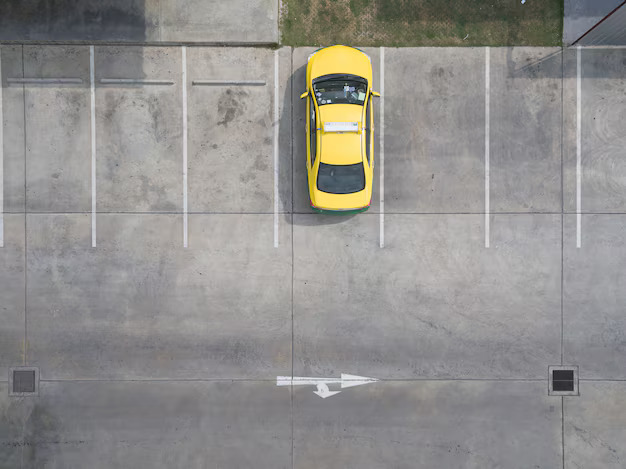

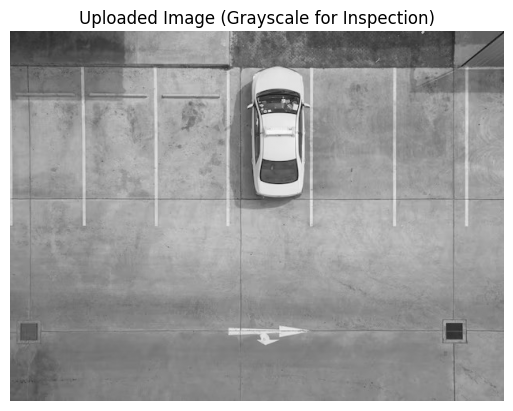


image 1/1 /content/parking lot (2).jpg: 480x640 1 car, 74.7ms
Speed: 4.1ms preprocess, 74.7ms inference, 2.1ms postprocess per image at shape (1, 3, 480, 640)

Detected object classes (all): {'car': 1}


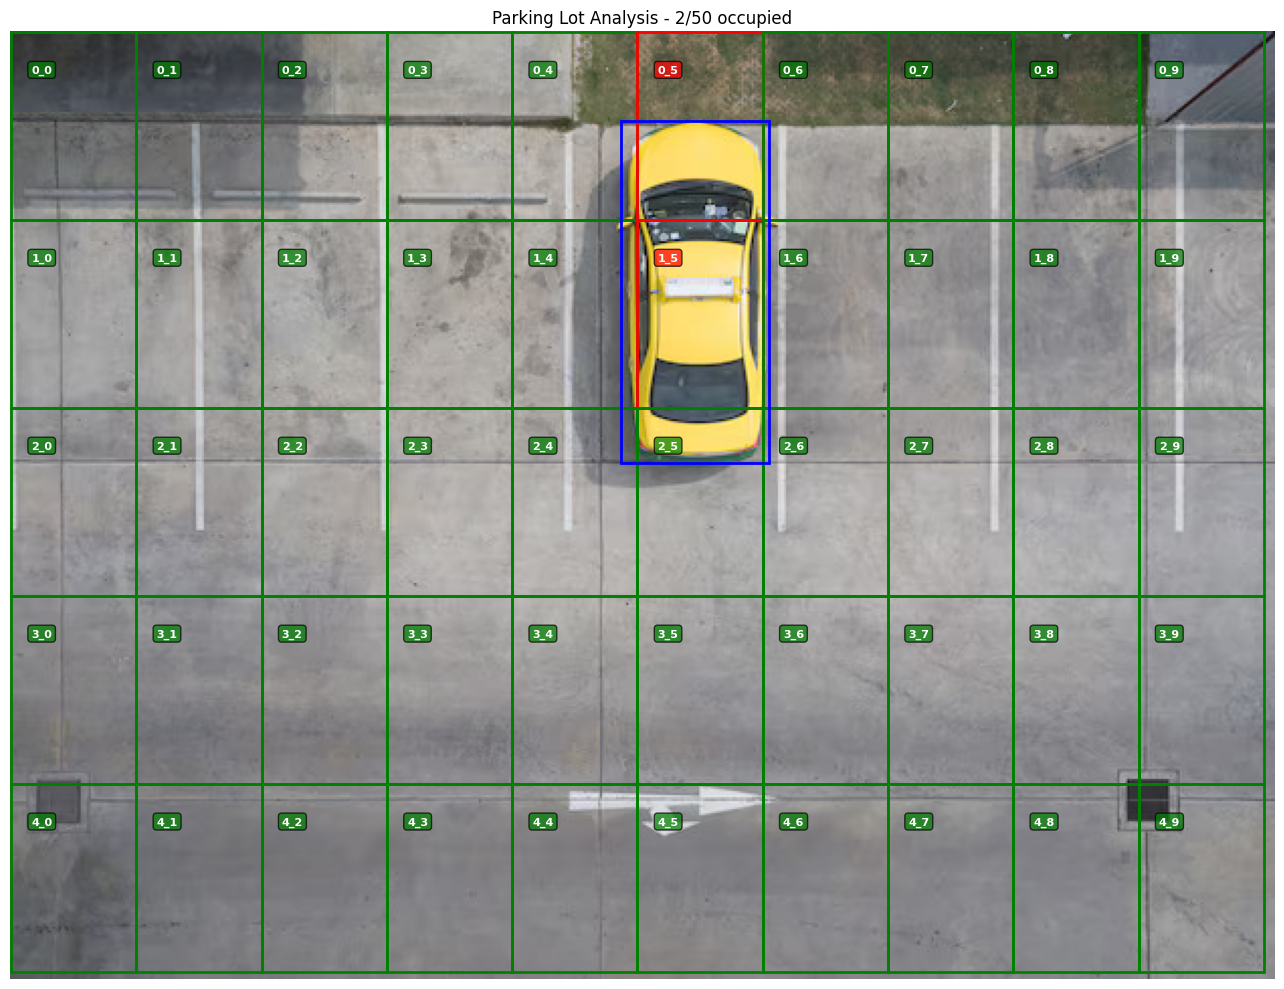


📊 Parking Statistics:
Total spaces: 50
Occupied: 2
Available: 48
Utilization: 4.0%
Vehicles detected: 1


In [30]:
# Upload image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Display uploaded image
display(Image(image_path))

# Load image for processing
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
valid_parking_spaces = None
# Display the grayscale image to inspect car visibility
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(img_gray, cmap='gray')
plt.title('Uploaded Image (Grayscale for Inspection)')
plt.axis('off')
plt.show()

# Detect vehicles (using YOLO - much better!)
result_img, detections = detect_vehicles_yolo(image_path)

# Create parking grid
spaces = create_parking_grid_with_mask(img_rgb.shape, grid_size=(5, 10),
                                       valid_spaces=valid_parking_spaces)

# Check occupancy
spaces = check_parking_occupancy(spaces, detections)

# Visualize
visualize_parking_lot(img_rgb, spaces, detections)

# Statistics
total = len(spaces)
occupied = sum(s['occupied'] for s in spaces)
available = total - occupied
utilization = (occupied / total) * 100

print(f"\n📊 Parking Statistics:")
print(f"Total spaces: {total}")
print(f"Occupied: {occupied}")
print(f"Available: {available}")
print(f"Utilization: {utilization:.1f}%")
print(f"Vehicles detected: {len(detections)}")